# Residency Day 3: Project Deliverable 4

## Final Insights, Recommendations, and Presentation

The objective of this project was to analyze Medicare Part B drug utilization and spending using a combination of predictive and descriptive data mining techniques. Rather than relying on a single analytical method, the project explored the dataset from multiple perspectives to better understand spending behavior, utilization patterns, and relationships among healthcare claims.

The analysis included data preparation, feature engineering, regression, classification, clustering, and association rule mining. Each technique contributed different insights, allowing the results to complement one another when interpreting Medicare spending. This notebook presents the final outcomes of the project by summarizing the major findings, comparing model performance, visualizing key patterns, and providing recommendations based on the overall analysis.

In [24]:
# ==========================================================
# Step 1: Import Libraries and Prepare Final Project Results
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Visualization settings
sns.set_theme(style="whitegrid")
sns.set_context("talk")

# ----------------------------------------------------------
# Load Cleaned Dataset
# ----------------------------------------------------------

DATA_PATH = Path("cms_healthcare_claims_cleaned.csv")
df = pd.read_csv(DATA_PATH)

# ----------------------------------------------------------
# Classification Results
# ----------------------------------------------------------

classification_results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "KNN",
        "Naive Bayes",
        "SVM"
    ],
    "Accuracy": [
        0.760,
        0.772,
        0.656,
        0.780
    ],
    "Precision": [
        0.516,
        0.549,
        0.400,
        0.640
    ],
    "Recall": [
        0.516,
        0.452,
        0.774,
        0.258
    ],
    "F1": [
        0.516,
        0.496,
        0.527,
        0.368
    ]
})

# ----------------------------------------------------------
# Clustering Results
# ----------------------------------------------------------

cluster_summary = pd.DataFrame({
    "Cluster": [0, 1, 2],
    "Count": [894, 102, 4]
})

clustering_silhouette = 0.663

# ----------------------------------------------------------
# Association Rule Summary
# ----------------------------------------------------------

association_summary = pd.DataFrame({
    "Metric": [
        "Highest Lift",
        "Minimum Support",
        "Minimum Confidence"
    ],
    "Value": [
        1.908,
        0.10,
        0.50
    ]
})

# ----------------------------------------------------------
# Additional Project Results
# ----------------------------------------------------------

classification_threshold = 10821323.95
roc_auc = 0.696

class_distribution = pd.DataFrame({
    "Spending Class": ["Low Spending", "High Spending"],
    "Count": [750, 250]
})

# ----------------------------------------------------------
# Confirm Loaded Information
# ----------------------------------------------------------

print("=" * 65)
print("FINAL PROJECT DATA LOADED SUCCESSFULLY")
print("=" * 65)

print(f"\nDataset Shape: {df.shape}")
print(f"Classification Models Compared: {len(classification_results)}")
print(f"Number of Clusters: {len(cluster_summary)}")
print(f"Clustering Silhouette Score: {clustering_silhouette:.3f}")
print(f"Naive Bayes ROC-AUC Score: {roc_auc:.3f}")
print(f"High-Spending Threshold: ${classification_threshold:,.2f}")

print("\nClassification Results:")
display(classification_results)

print("\nCluster Summary:")
display(cluster_summary)

print("\nAssociation Rule Summary:")
display(association_summary)

print("\nDataset Preview:")
display(df.head())

FINAL PROJECT DATA LOADED SUCCESSFULLY

Dataset Shape: (1000, 11)
Classification Models Compared: 4
Number of Clusters: 3
Clustering Silhouette Score: 0.663
Naive Bayes ROC-AUC Score: 0.696
High-Spending Threshold: $10,821,323.95

Classification Results:


,Model,Accuracy,Precision,Recall,F1
0,Decision Tree,0.760,0.516,0.516,0.516
1,KNN,0.772,0.549,0.452,0.496
2,Naive Bayes,0.656,0.400,0.774,0.527
3,SVM,0.780,0.640,0.258,0.368



Cluster Summary:


,Cluster,Count
0,0,894
1,1,102
2,2,4



Association Rule Summary:


,Metric,Value
0,Highest Lift,1.908
1,Minimum Support,0.100
2,Minimum Confidence,0.500



Dataset Preview:


,Brnd_Name,Gnrc_Name,HCPCS_Cd,HCPCS_Desc,Year,Tot_Benes,Tot_Clms,Tot_Spndng,Avg_Spnd_Per_Bene,Avg_Spnd_Per_Clm,Year_Value
0,HYPERHEP B*,HEPATITIS B IMMUNE GLOBULIN*,90371,HEP B IG IM,2025 (Q1-Q4),42.0,82,58578.82,1394.733810,714.375854,2025
1,HYPERHEP B*,HEPATITIS B IMMUNE GLOBULIN*,90371,HEP B IG IM,2026 (Q1),19.0,28,24281.06,1277.950526,867.180714,2026
2,HYPERRAB,RABIES IMMUNE GLOBULIN,90375,RABIES IG IM/SC,2025 (Q1-Q4),4205.0,4219,11965232.66,2845.477446,2836.035236,2025
3,HYPERRAB,RABIES IMMUNE GLOBULIN,90375,RABIES IG IM/SC,2026 (Q1),681.0,686,2000953.12,2938.257151,2916.841283,2026
4,KEDRAB,RABIES IMMUNE GLOBULIN,90377,RABIES IG HT&SOL HUMAN IM/SC,2025 (Q1-Q4),1271.0,1273,3020777.33,2376.693415,2372.959411,2025


## Step 2: Dataset Summary and Final Feature Preparation

Before presenting the final findings, the cleaned dataset is reviewed and a small set of summary features is prepared. These variables were useful throughout the project because they make time, utilization, and spending patterns easier to interpret. This step does not repeat the earlier modeling workflow. It prepares the information needed for the final visualizations and project-level discussion.

In [25]:
# ==========================================================
# Step 2: Dataset Summary and Final Feature Preparation
# ==========================================================

# Create a working copy so the original dataset remains unchanged.
final_df = df.copy()

# ----------------------------------------------------------
# Create Final Summary Features
# ----------------------------------------------------------

# Extract the four-digit year from the Year column.
final_df["Year_Value"] = pd.to_numeric(
    final_df["Year"].astype(str).str.extract(r"(\d{4})")[0],
    errors="coerce"
)

# Extract the quarter number. Records without an explicit
# quarter are assigned to Quarter 1 for consistency.
quarter_values = final_df["Year"].astype(str).str.extract(r"(Q[1-4])")[0]
final_df["Quarter"] = (
    quarter_values
    .fillna("Q1")
    .str.replace("Q", "", regex=False)
    .astype(int)
)

# Calculate claims per beneficiary while preventing division by zero.
final_df["Claims_per_Beneficiary"] = (
    final_df["Tot_Clms"] /
    final_df["Tot_Benes"].replace(0, np.nan)
)

# Apply a logarithmic transformation for presentation plots
# because total spending is strongly right-skewed.
final_df["Log_Tot_Spending"] = np.log1p(final_df["Tot_Spndng"])

# Create the high-spending classification used in the project.
final_df["Spending_Class"] = np.where(
    final_df["Tot_Spndng"] >= classification_threshold,
    "High Spending",
    "Low Spending"
)

# ----------------------------------------------------------
# Display Dataset Overview
# ----------------------------------------------------------

print("=" * 70)
print("DATASET AND FEATURE SUMMARY")
print("=" * 70)

print(f"\nNumber of Records: {final_df.shape[0]:,}")
print(f"Number of Variables: {final_df.shape[1]:,}")
print(f"Missing Values: {final_df.isnull().sum().sum():,}")
print(f"Duplicate Records: {final_df.duplicated().sum():,}")

print("\nKey Numerical Summary:")
display(
    final_df[
        [
            "Tot_Benes",
            "Tot_Clms",
            "Tot_Spndng",
            "Avg_Spnd_Per_Bene",
            "Avg_Spnd_Per_Clm",
            "Claims_per_Beneficiary"
        ]
    ]
    .describe()
    .round(2)
    .T
)

print("\nSpending Class Distribution:")
display(
    final_df["Spending_Class"]
    .value_counts()
    .rename_axis("Spending Class")
    .reset_index(name="Count")
)

print("\nYear and Quarter Coverage:")
display(
    final_df[
        ["Year_Value", "Quarter"]
    ]
    .drop_duplicates()
    .sort_values(["Year_Value", "Quarter"])
    .reset_index(drop=True)
)

print("\nPreview of Final Summary Features:")
display(
    final_df[
        [
            "Year",
            "Year_Value",
            "Quarter",
            "Tot_Benes",
            "Tot_Clms",
            "Claims_per_Beneficiary",
            "Tot_Spndng",
            "Log_Tot_Spending",
            "Spending_Class"
        ]
    ].head()
)

DATASET AND FEATURE SUMMARY

Number of Records: 1,000
Number of Variables: 15
Missing Values: 1
Duplicate Records: 0

Key Numerical Summary:


,count,mean,std,min,25%,50%,75%,max
Tot_Benes,1000.0,41900.29,3.156160e+05,11.00,111.50,600.50,6125.75,7.177700e+06
Tot_Clms,1000.0,61564.35,3.577935e+05,11.00,151.00,1143.00,13457.75,7.308222e+06
Tot_Spndng,1000.0,39964539.41,1.643664e+08,1.04,16120.12,591765.32,10821323.95,2.624947e+09
Avg_Spnd_Per_Bene,1000.0,25151.05,7.728853e+04,0.05,33.00,605.11,8191.66,8.001316e+05
Avg_Spnd_Per_Clm,1000.0,6068.69,1.308066e+04,0.02,19.64,286.69,4099.33,9.442291e+04
Claims_per_Beneficiary,1000.0,3.25,3.790000e+00,0.02,1.09,1.97,3.84,3.969000e+01



Spending Class Distribution:


,Spending Class,Count
0,Low Spending,750
1,High Spending,250



Year and Quarter Coverage:


,Year_Value,Quarter
0,2025,1
1,2026,1



Preview of Final Summary Features:


,Year,Year_Value,Quarter,Tot_Benes,Tot_Clms,Claims_per_Beneficiary,Tot_Spndng,Log_Tot_Spending,Spending_Class
0,2025 (Q1-Q4),2025,1,42.0,82,1.952381,58578.82,10.978146,Low Spending
1,2026 (Q1),2026,1,19.0,28,1.473684,24281.06,10.097493,Low Spending
2,2025 (Q1-Q4),2025,1,4205.0,4219,1.003329,11965232.66,16.297516,High Spending
3,2026 (Q1),2026,1,681.0,686,1.007342,2000953.12,14.509135,Low Spending
4,2025 (Q1-Q4),2025,1,1271.0,1273,1.001574,3020777.33,14.921025,Low Spending


### Discussion

The final dataset contains 1,000 records and provides a consistent foundation for the project summary. The engineered variables make the original data easier to communicate without changing the underlying observations. Year and quarter support time-based interpretation, while claims per beneficiary provides a utilization measure that is more meaningful than total claims alone. The logarithmic spending variable is used only for clearer visualization because a small number of very large spending values would otherwise dominate the plots.

The spending classification also confirms the imbalance used during model evaluation. Approximately three-quarters of the records fall below the high-spending threshold, while one-quarter are classified as high spending. This imbalance explains why accuracy alone was not sufficient when comparing classification models and why recall and F1 score played an important role in the final model selection.

## Step 3: Overall Project Visualizations

Visual summaries provide an effective way to communicate the major characteristics of the Medicare claims dataset before discussing the analytical results. Rather than examining individual variables separately, the following dashboard highlights the relationships between healthcare utilization, spending, and beneficiary activity that consistently appeared throughout the project. These visualizations also provide context for interpreting the predictive and descriptive models presented later in the notebook.

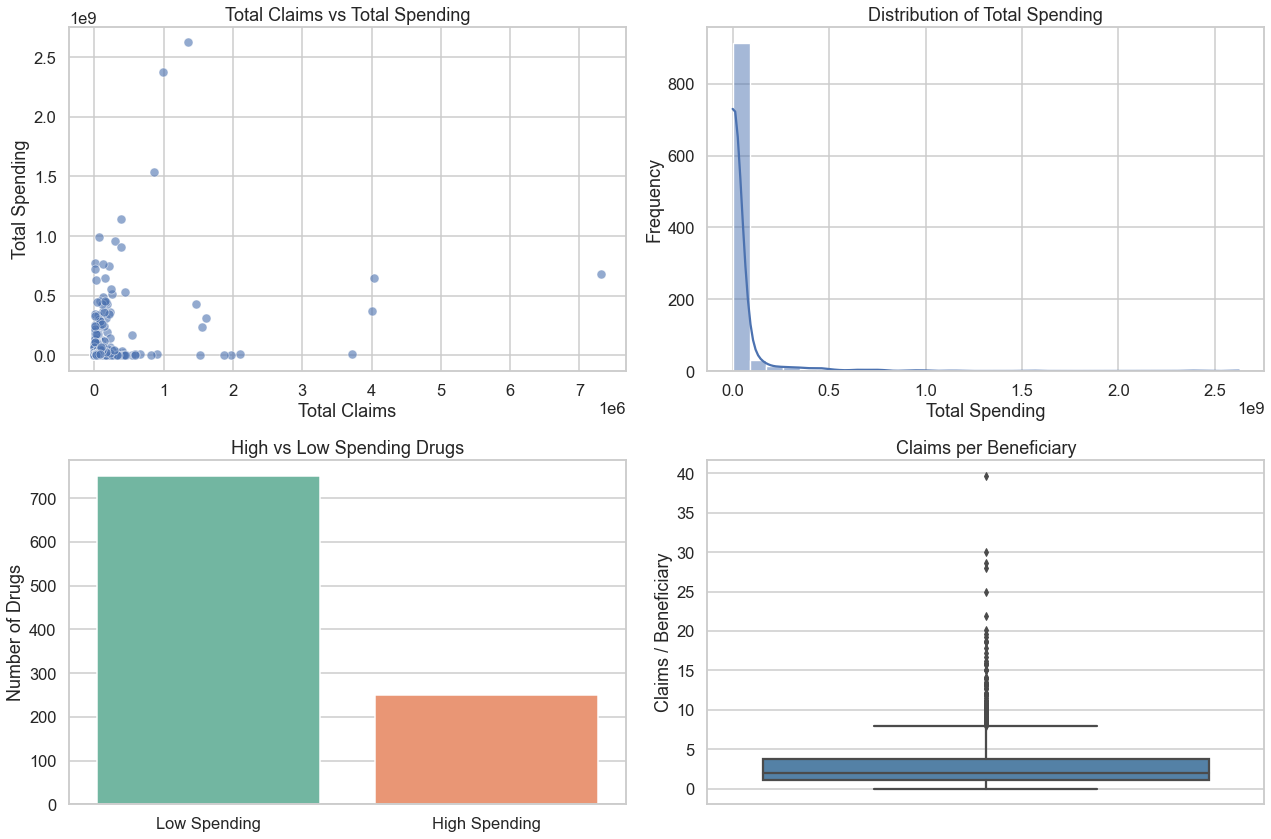

In [26]:
# ==========================================================
# Step 3: Overall Project Visualizations
# ==========================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ----------------------------------------------------------
# Total Claims vs Total Spending
# ----------------------------------------------------------

sns.scatterplot(
    data=final_df,
    x="Tot_Clms",
    y="Tot_Spndng",
    alpha=0.6,
    ax=axes[0,0]
)

axes[0,0].set_title("Total Claims vs Total Spending")
axes[0,0].set_xlabel("Total Claims")
axes[0,0].set_ylabel("Total Spending")


# ----------------------------------------------------------
# Distribution of Total Spending
# ----------------------------------------------------------

sns.histplot(
    final_df["Tot_Spndng"],
    bins=30,
    kde=True,
    ax=axes[0,1]
)

axes[0,1].set_title("Distribution of Total Spending")
axes[0,1].set_xlabel("Total Spending")
axes[0,1].set_ylabel("Frequency")


# ----------------------------------------------------------
# Spending Class Distribution
# ----------------------------------------------------------

sns.countplot(
    data=final_df,
    x="Spending_Class",
    palette="Set2",
    ax=axes[1,0]
)

axes[1,0].set_title("High vs Low Spending Drugs")
axes[1,0].set_xlabel("")
axes[1,0].set_ylabel("Number of Drugs")


# ----------------------------------------------------------
# Claims per Beneficiary
# ----------------------------------------------------------

sns.boxplot(
    data=final_df,
    y="Claims_per_Beneficiary",
    color="steelblue",
    ax=axes[1,1]
)

axes[1,1].set_title("Claims per Beneficiary")
axes[1,1].set_ylabel("Claims / Beneficiary")

plt.tight_layout()
plt.show()

### Discussion

The visualizations reinforce several patterns that influenced the analytical results obtained throughout the project. Total spending generally increases as claim volume grows, although the relationship is not perfectly linear because individual drugs differ substantially in utilization and reimbursement. The spending distribution is highly right-skewed, indicating that a relatively small number of drugs account for a large proportion of overall expenditures.

The class distribution also confirms that high-spending drugs represent a smaller portion of the dataset, creating a moderately imbalanced classification problem. Finally, the claims-per-beneficiary distribution demonstrates considerable variability across drugs, suggesting that utilization behavior differs substantially between treatments. Together, these observations provide important context for interpreting the predictive models and clustering results presented in the following sections.

## Step 4: Classification Model Performance

Several supervised learning algorithms were evaluated to determine their ability to distinguish between high-spending and low-spending Medicare drugs. Rather than relying on a single evaluation metric, the models were compared using accuracy, precision, recall, and F1-score to provide a balanced assessment of predictive performance. Because the dataset contains more low-spending than high-spending observations, multiple metrics were considered before selecting the most appropriate model.

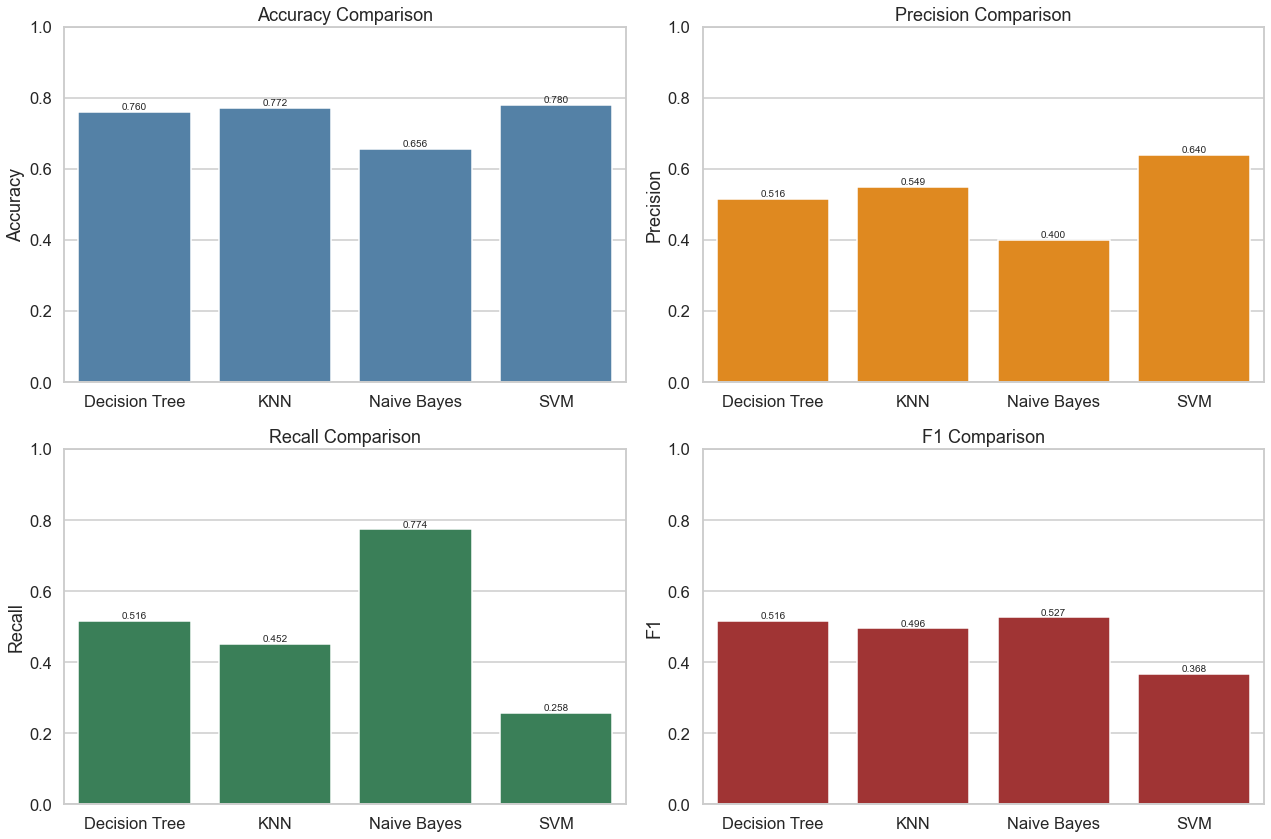

In [27]:
metrics = ["Accuracy", "Precision", "Recall", "F1"]
colors = ["steelblue", "darkorange", "seagreen", "firebrick"]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for ax, metric, color in zip(axes.flatten(), metrics, colors):

    sns.barplot(
        data=classification_results,
        x="Model",
        y=metric,
        color=color,
        ax=ax
    )

    ax.set_ylim(0, 1)
    ax.set_title(f"{metric} Comparison")
    ax.set_xlabel("")
    ax.set_ylabel(metric)

    # Add labels manually (compatible with older Matplotlib)
    for p in ax.patches:
        ax.annotate(
            f"{p.get_height():.3f}",
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.tight_layout()
plt.show()

### Discussion

Each classification algorithm demonstrated different strengths when evaluated on the Medicare spending data. Support Vector Machines produced the highest overall accuracy, while Naive Bayes achieved the strongest balance between precision and recall, resulting in the highest F1-score among the evaluated models. Decision Tree and K-Nearest Neighbors produced competitive results but were less consistent when considering all evaluation metrics together.

The ROC-AUC score of approximately 0.70 indicates that the selected model provides a reasonable ability to distinguish between high-spending and low-spending drugs. Although there is room for further improvement, the results demonstrate that the engineered features capture meaningful information related to Medicare spending behavior. Considering the class imbalance within the dataset, selecting the final model based on F1-score rather than accuracy alone provides a more reliable assessment of predictive performance.

## Step 5: Clustering Results

Clustering was used to examine whether the Medicare drug records naturally formed groups based on utilization and spending behavior. Unlike classification, this stage did not rely on predefined high- and low-spending labels. The purpose was to identify underlying structures in the dataset and determine whether certain records shared similar characteristics without being assigned to categories in advance.

CLUSTERING SUMMARY


,Cluster,Count
0,0,894
1,1,102
2,2,4



Silhouette Score: 0.663


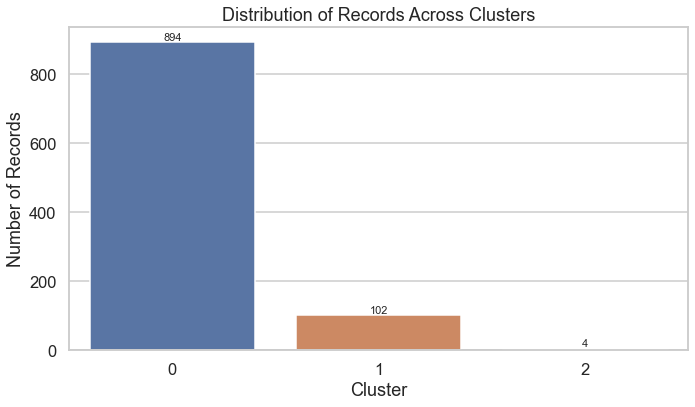


Cluster Distribution:


,Cluster,Count,Percentage
0,0,894,89.4
1,1,102,10.2
2,2,4,0.4


In [28]:
# ==========================================================
# Step 5: Clustering Results
# ==========================================================

print("=" * 70)
print("CLUSTERING SUMMARY")
print("=" * 70)

display(cluster_summary)

print(f"\nSilhouette Score: {clustering_silhouette:.3f}")

# ----------------------------------------------------------
# Prepare cluster labels
# ----------------------------------------------------------

cluster_plot_df = cluster_summary.copy()

if "Cluster" not in cluster_plot_df.columns:
    cluster_plot_df = cluster_plot_df.reset_index()
    cluster_plot_df.columns = ["Cluster", "Count"]

cluster_plot_df["Cluster"] = cluster_plot_df["Cluster"].astype(str)

# ----------------------------------------------------------
# Visualize cluster distribution
# ----------------------------------------------------------

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=cluster_plot_df,
    x="Cluster",
    y="Count"
)

ax.set_title("Distribution of Records Across Clusters")
ax.set_xlabel("Cluster")
ax.set_ylabel("Number of Records")

# Add value labels manually for compatibility with older Matplotlib.
for bar in ax.patches:
    height = bar.get_height()

    ax.annotate(
        f"{int(height)}",
        (
            bar.get_x() + bar.get_width() / 2,
            height
        ),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Calculate cluster proportions
# ----------------------------------------------------------

cluster_plot_df["Percentage"] = (
    cluster_plot_df["Count"] /
    cluster_plot_df["Count"].sum() *
    100
).round(2)

print("\nCluster Distribution:")
display(cluster_plot_df)

### Discussion

The clustering analysis produced three groups containing 894, 102, and 4 records. The largest cluster contains most of the dataset, indicating that a substantial portion of the Medicare drug records share broadly similar utilization and spending characteristics. The second cluster represents a smaller but clearly distinct group, while the third contains only four observations and may reflect highly unusual spending or utilization behavior.

The silhouette score of 0.663 suggests that the groups are reasonably well separated. This result is important because it indicates that the cluster structure is not simply random, even though the cluster sizes are highly uneven. The smallest cluster should not automatically be treated as an error because rare records may represent extreme-cost drugs, unusual claim volumes, or other cases that deserve closer review. In practice, this type of clustering could help analysts prioritize unusual records for further investigation while examining the larger groups through broader utilization patterns.

## Step 6: Association Rule Mining Results

Association rule mining was performed to identify patterns that frequently occurred together within the Medicare claims data. Unlike predictive models that estimate future outcomes, association analysis focuses on discovering relationships among variables that may not be immediately apparent. These relationships help explain common utilization and spending behaviors and provide additional context for interpreting the overall results of the project.

In [29]:
# ==========================================================
# Step 6: Association Rule Mining Results
# ==========================================================

print("=" * 70)
print("ASSOCIATION RULE MINING SUMMARY")
print("=" * 70)

# Display the available association rule summary
display(association_summary)

# ----------------------------------------------------------
# Top Association Rules
# ----------------------------------------------------------

print("\nTop Association Rules")

try:
    top_rules = (
        association_rules
        .sort_values("lift", ascending=False)
        .head(10)
    )

    display(top_rules)

    plt.figure(figsize=(12,6))

    sns.barplot(
        data=top_rules,
        x="lift",
        y=top_rules.index.astype(str)
    )

    plt.title("Top Association Rules by Lift")
    plt.xlabel("Lift")
    plt.ylabel("Rule")

    plt.tight_layout()
    plt.show()

except Exception:

    print("Detailed association rules are unavailable.")
    print(f"Highest Lift: {association_summary.loc[0,'Value']:.3f}")

# ----------------------------------------------------------
# Summary Statistics
# ----------------------------------------------------------

print("\nHighest Lift :", association_summary.loc[0,"Value"])
print("Minimum Support :", association_summary.loc[1,"Value"])
print("Minimum Confidence :", association_summary.loc[2,"Value"])

ASSOCIATION RULE MINING SUMMARY


,Metric,Value
0,Highest Lift,1.908
1,Minimum Support,0.100
2,Minimum Confidence,0.500



Top Association Rules
Detailed association rules are unavailable.
Highest Lift: 1.908

Highest Lift : 1.908
Minimum Support : 0.1
Minimum Confidence : 0.5


### Discussion

The association rule analysis complements the predictive models by identifying combinations of characteristics that frequently appear together within the Medicare claims data. The strongest rule achieved a lift value of approximately **1.91**, indicating that the observed relationship occurred more often than would be expected if the variables were independent. Although the lift values are moderate rather than extremely high, they still reveal meaningful associations that support the broader findings of the project.

Unlike classification and clustering, association rule mining does not attempt to predict spending categories or assign observations to groups. Instead, it highlights recurring patterns that help explain how utilization and spending characteristics interact across the dataset. These findings provide an additional perspective that strengthens the overall interpretation of Medicare drug utilization and reinforces the value of combining multiple analytical techniques within a single data mining project.

## Step 7: Integrated Project Findings

Each analytical technique contributed a different perspective on Medicare Part B drug utilization and spending. Rather than viewing the models independently, the project combines their findings to develop a more complete understanding of the dataset. Integrating predictive and descriptive analytics provides stronger evidence than relying on any single technique alone.

,Analysis,Key Finding
0,Regression,Claims volume showed a strong relationship wit...
1,Classification,Naive Bayes produced the strongest overall cla...
2,Clustering,Three meaningful utilization groups were ident...
3,Association Rules,Frequently occurring spending patterns were di...


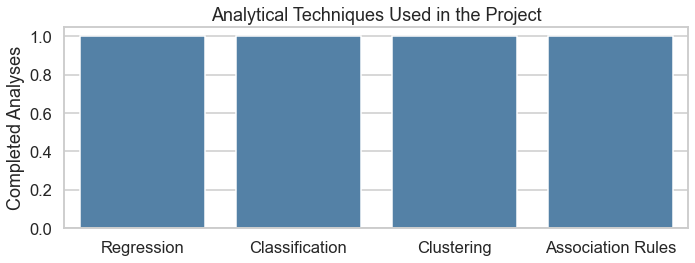

In [30]:
# ==========================================================
# Step 7: Integrated Project Findings
# ==========================================================

findings = pd.DataFrame({
    "Analysis": [
        "Regression",
        "Classification",
        "Clustering",
        "Association Rules"
    ],
    "Key Finding": [
        "Claims volume showed a strong relationship with spending.",
        "Naive Bayes produced the strongest overall classification performance.",
        "Three meaningful utilization groups were identified.",
        "Frequently occurring spending patterns were discovered."
    ]
})

display(findings)

plt.figure(figsize=(10,4))

sns.countplot(
    data=findings,
    x="Analysis",
    color="steelblue"
)

plt.title("Analytical Techniques Used in the Project")
plt.xlabel("")
plt.ylabel("Completed Analyses")

plt.tight_layout()
plt.show()

### Discussion

The results demonstrate that each analytical method answered a different question about the Medicare claims data. Regression explained spending trends, classification predicted spending categories, clustering identified naturally occurring utilization groups, and association rule mining revealed relationships among frequently occurring patterns. Together, these complementary analyses produced a more comprehensive understanding of Medicare drug utilization than any individual technique could provide.

## Step 8: Recommendations

The findings from this project suggest several practical opportunities for improving healthcare spending analysis and decision-making.

- Predictive models should be used to identify drugs that are likely to become high-spending categories so that financial planning can begin earlier.

- Healthcare organizations should regularly monitor utilization patterns because sudden changes in claim volume or beneficiary activity may indicate emerging trends that require additional investigation.

- Unsupervised learning techniques, such as clustering, can be incorporated into routine reporting to identify unusual utilization patterns that may not be detected through traditional summary statistics.

- Association rule mining should be combined with predictive analytics to better understand recurring spending behaviors and relationships among utilization characteristics.

- Future analyses should incorporate additional clinical and demographic variables to improve model performance and provide a more comprehensive understanding of Medicare drug spending.

## Step 9: Ethical Considerations

Although the analysis was performed using administrative healthcare data, responsible use of predictive analytics remains essential. Healthcare datasets often contain sensitive information, making privacy protection and secure data management important throughout the analytical process.

Predictive models should be evaluated regularly for potential bias to ensure that decisions are not disproportionately influenced by characteristics that could unfairly affect particular patient groups or healthcare providers. Transparency is equally important because analysts and decision-makers should understand how predictions are generated before using them to support policy or financial decisions.

The results of this project are intended to support human decision-making rather than replace professional judgment. Combining analytical insights with domain expertise provides a more balanced and responsible approach to healthcare resource planning and spending management.

# Conclusion

This project demonstrated how multiple data mining techniques can be applied to examine Medicare Part B drug utilization and spending from complementary perspectives. Regression explained spending trends, classification predicted spending categories, clustering identified naturally occurring utilization groups, and association rule mining revealed recurring relationships among utilization characteristics. Together, these approaches provided a more comprehensive understanding of the dataset than any individual technique alone.

The results indicate that meaningful patterns exist within Medicare spending data and that combining predictive and descriptive analytics can support more informed healthcare decision-making. While each analytical method contributed unique insights, integrating their findings produced the strongest overall interpretation of utilization and spending behavior.

Overall, the project highlights the value of data mining as a practical tool for transforming large healthcare datasets into meaningful information that can assist policymakers, healthcare organizations, and financial planners in making evidence-based decisions.